# Veri Keşfi

`data/raw/` klasöründeki bir hisse senedi CSV dosyasını yükleyip temel istatistiklerini ve zaman serisi grafiklerini inceler.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

SYMBOL = "THYAO.IS"  # data/raw/ altındaki .csv dosyalarından biriyle değiştirin
DATA_PATH = f"../data/raw/{SYMBOL}.csv"

In [2]:
df = pd.read_csv(DATA_PATH, index_col="Date", parse_dates=True)
df.head()

,Adj Close,Close,High,Low,Open,Volume
Date,,,,,,
2021-07-26,12.025445,12.31,12.78,12.30,12.74,51258820
2021-07-27,12.259896,12.55,12.60,12.24,12.31,90420698
2021-07-28,12.269666,12.56,12.66,12.45,12.57,53733465
2021-07-29,12.484580,12.78,12.91,12.63,12.65,49541199
2021-07-30,12.435735,12.73,12.84,12.65,12.70,38063021


In [3]:
df.info()

<class 'pandas.DataFrame'>
DatetimeIndex: 1251 entries, 2021-07-26 to 2026-07-20
Data columns (total 6 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Adj Close  1251 non-null   float64
 1   Close      1251 non-null   float64
 2   High       1251 non-null   float64
 3   Low        1251 non-null   float64
 4   Open       1251 non-null   float64
 5   Volume     1251 non-null   int64  
dtypes: float64(5), int64(1)
memory usage: 68.4 KB


In [4]:
df.describe()

,Adj Close,Close,High,Low,Open,Volume
count,1251.000000,1251.000000,1251.000000,1251.000000,1251.000000,1.251000e+03
mean,200.143289,203.430008,206.465476,200.858849,203.664924,5.679037e+07
std,111.464927,112.789272,114.199604,111.755606,113.035376,4.167872e+07
min,11.908217,12.190000,12.270000,12.100000,12.160000,0.000000e+00
25%,95.417160,97.674999,99.400002,96.625000,97.699997,2.935609e+07
50%,254.478333,260.000000,264.000000,256.299988,260.750000,4.113401e+07
75%,293.279739,297.000000,300.250000,293.750000,297.000000,7.098950e+07
max,348.250000,348.250000,355.500000,345.250000,349.750000,2.696631e+08


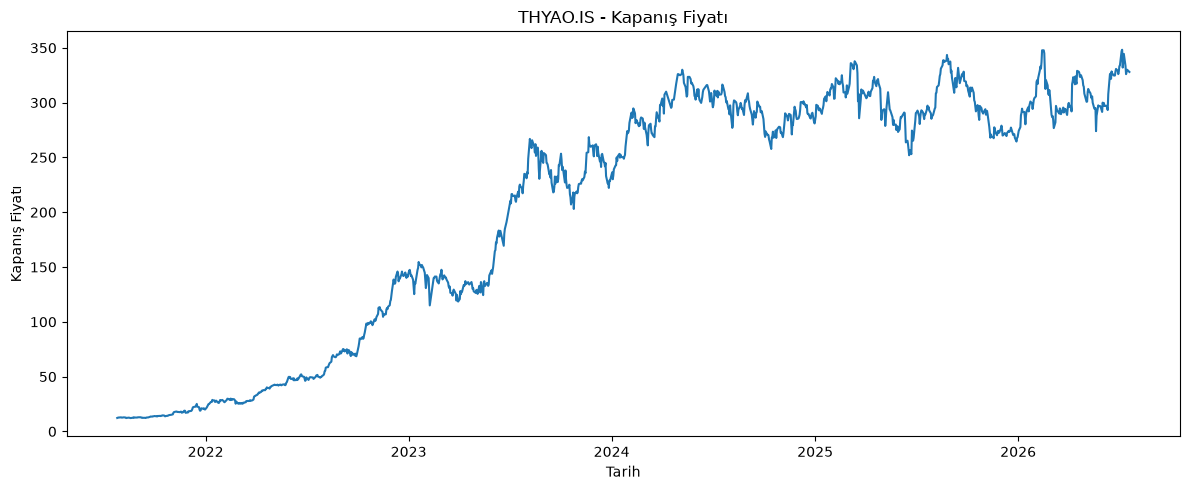

In [5]:
plt.figure(figsize=(12, 5))
plt.plot(df.index, df["Close"])
plt.title(f"{SYMBOL} - Kapanış Fiyatı")
plt.xlabel("Tarih")
plt.ylabel("Kapanış Fiyatı")
plt.tight_layout()
plt.show()

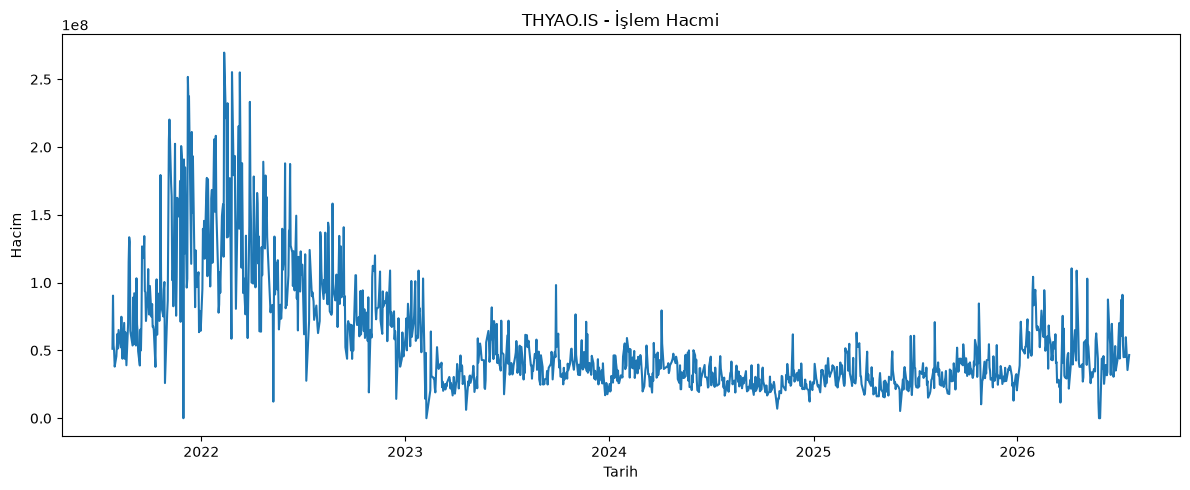

In [6]:
plt.figure(figsize=(12, 5))
plt.plot(df.index, df["Volume"])
plt.title(f"{SYMBOL} - İşlem Hacmi")
plt.xlabel("Tarih")
plt.ylabel("Hacim")
plt.tight_layout()
plt.show()

## Eksik Değer Kontrolü ve Temizleme

In [ ]:
print("Eksik değer sayısı (sütun bazında):")
print(df.isna().sum())

missing_ratio = df.isna().mean().mean()
print(f"\nToplam eksik değer oranı: {missing_ratio:.2%}")

# Zaman serisi olduğu için önce ileri doldurma (ffill) uygulanır;
# serinin başında kalan (doldurulamayan) NaN'lar varsa o satırlar atılır (dropna)
df = df.ffill()
df = df.dropna()

print(f"\nTemizlik sonrası eksik değer sayısı: {df.isna().sum().sum()}")
print(f"Temizlik sonrası satır sayısı: {len(df)}")

## Teknik Göstergeler: SMA (20), RSI (14), MACD

`pandas-ta` kurulu değilse diye göstergeler elle (pandas ile) hesaplanır.

In [ ]:
try:
    import pandas_ta as ta
    HAS_PANDAS_TA = True
except ImportError:
    HAS_PANDAS_TA = False

if HAS_PANDAS_TA:
    df["SMA_20"] = ta.sma(df["Close"], length=20)
    df["RSI_14"] = ta.rsi(df["Close"], length=14)
    macd_df = ta.macd(df["Close"], fast=12, slow=26, signal=9)
    df["MACD"] = macd_df["MACD_12_26_9"]
    df["MACD_Signal"] = macd_df["MACDs_12_26_9"]
    df["MACD_Hist"] = macd_df["MACDh_12_26_9"]
else:
    # 20 günlük Basit Hareketli Ortalama (SMA)
    df["SMA_20"] = df["Close"].rolling(window=20).mean()

    # 14 günlük RSI (Relative Strength Index)
    def compute_rsi(series, period=14):
        delta = series.diff()
        gain = delta.clip(lower=0)
        loss = -delta.clip(upper=0)
        avg_gain = gain.ewm(alpha=1 / period, min_periods=period, adjust=False).mean()
        avg_loss = loss.ewm(alpha=1 / period, min_periods=period, adjust=False).mean()
        rs = avg_gain / avg_loss
        return 100 - (100 / (1 + rs))

    df["RSI_14"] = compute_rsi(df["Close"], period=14)

    # MACD: 12 günlük EMA - 26 günlük EMA, Sinyal çizgisi: MACD'nin 9 günlük EMA'sı
    ema_12 = df["Close"].ewm(span=12, adjust=False).mean()
    ema_26 = df["Close"].ewm(span=26, adjust=False).mean()
    df["MACD"] = ema_12 - ema_26
    df["MACD_Signal"] = df["MACD"].ewm(span=9, adjust=False).mean()
    df["MACD_Hist"] = df["MACD"] - df["MACD_Signal"]

df[["Close", "SMA_20", "RSI_14", "MACD", "MACD_Signal", "MACD_Hist"]].tail()

## Kapanış Fiyatı ve Teknik Göstergeler

RSI ve MACD, Close ile farklı ölçeklerde olduğundan tek eksende (dual-axis) üst üste
çizmek yanıltıcı olur; bu yüzden ortak tarih eksenini paylaşan ayrı panellerde gösterilir.

In [ ]:
fig, axes = plt.subplots(3, 1, figsize=(12, 10), sharex=True,
                          gridspec_kw={"height_ratios": [2, 1, 1]})

# Panel 1: Close + SMA 20
axes[0].plot(df.index, df["Close"], label="Close", color="#2563EB", linewidth=1.5)
axes[0].plot(df.index, df["SMA_20"], label="SMA 20", color="#F59E0B", linewidth=1.5)
axes[0].set_title(f"{SYMBOL} - Kapanış Fiyatı ve SMA 20")
axes[0].set_ylabel("Fiyat")
axes[0].legend(loc="upper left", frameon=False)
axes[0].grid(alpha=0.2)

# Panel 2: RSI 14
axes[1].plot(df.index, df["RSI_14"], label="RSI 14", color="#059669", linewidth=1.5)
axes[1].axhline(70, color="#DC2626", linestyle="--", linewidth=1, alpha=0.6)
axes[1].axhline(30, color="#DC2626", linestyle="--", linewidth=1, alpha=0.6)
axes[1].set_title("RSI (14)")
axes[1].set_ylabel("RSI")
axes[1].set_ylim(0, 100)
axes[1].legend(loc="upper left", frameon=False)
axes[1].grid(alpha=0.2)

# Panel 3: MACD
axes[2].plot(df.index, df["MACD"], label="MACD", color="#7C3AED", linewidth=1.5)
axes[2].plot(df.index, df["MACD_Signal"], label="Sinyal", color="#DC2626", linewidth=1.5)
axes[2].bar(df.index, df["MACD_Hist"], label="Histogram", color="#9CA3AF", alpha=0.5, width=1.0)
axes[2].set_title("MACD (12, 26, 9)")
axes[2].set_xlabel("Tarih")
axes[2].set_ylabel("MACD")
axes[2].legend(loc="upper left", frameon=False)
axes[2].grid(alpha=0.2)

plt.tight_layout()
plt.show()